# Sobre la representación de películas como conjuntos

Debido a que MinHash y Jaccard trabajan con **conjuntos**, necesitamos convertir cada película en un conjunto de algo para poder compararlas.

Analizamos dos opciones:

*Opción A: Conjunto de usuarios*
Cada película = conjunto de usuarios que la calificaron positivamente (like = 1)

  - Pulp Fiction = {usuario_1, usuario_5, usuario_9, usuario_23, ...}
  - Forrest Gump = {usuario_1, usuario_3, usuario_9, usuario_41, ...}

Similitud = cuántos usuarios en común tienen ambas películas.

*Opción B: Conjunto de tags*
Cada película = conjunto de tags que le asignaron los usuarios

- Pulp Fiction = {"violence", "dark comedy", "cult", "nonlinear"}
- Forrest Gump = {"feel-good", "classic", "drama", "based on book"}

Similitud = cuántos tags en común tienen ambas películas.

**Elegimos la opción A, por:**
- 20M ratings vs 463K tags → conjuntos más grandes y representativos
- Ya tenemos like=1 calculado desde el preprocesamiento
- Dos películas con muchos usuarios en común gustan al mismo tipo de persona → similitud útil para recomendación

---

## Fase 3 — Similitud, MinHashing y LSH

Tenemos 27K películas. Comparar todos los pares posibles = O(N²) ≈ 365M comparaciones.

Solución: MinHash + LSH reducen esto a O(N) pares candidatos.



## 3.1 Similitud de Jaccard

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- Rango [0, 1]: 0 = sin elementos comunes, 1 = conjuntos idénticos
- Distancia de Jaccard: $d_J(A,B) = 1 - J(A,B)$
- Solo presencia/ausencia — no importa frecuencia ni orden

**En nuestro caso (Opción A):**
- A = conjunto de usuarios que dieron like a la película A
- B = conjunto de usuarios que dieron like a la película B
- J(A,B) alto → mismos usuarios las gustaron → películas similares



## 3.2 MinHashing

**Problema:** los conjuntos de usuarios son enormes (hasta 67K por película).

**Solución:** comprimir cada conjunto en una firma compacta de t enteros que preserva Jaccard.

**Teorema (Broder, 1997):**
Para una permutación aleatoria uniforme π:
$$Pr[h_\pi(A) = h_\pi(B)] = J(A, B)$$

La probabilidad de que el mínimo coincida = la similitud de Jaccard.

**Implementación práctica (sin permutaciones explícitas):**
Usamos funciones hash universales que simulan permutaciones:
$$h_{a,b}(x) = ((a \cdot x + b) \mod p) \mod N$$
donde $p$ es primo grande ($p > N$), $a, b$ enteros aleatorios.

**Firma de una película C con t funciones hash:**
$$sig(C) = [min_{x \in C} h_1(x),\ min_{x \in C} h_2(x),\ \ldots,\ min_{x \in C} h_t(x)]$$

**Similitud aproximada entre dos firmas:**
$$\hat{J}(A, B) = \frac{|\{i : sig(A)[i] = sig(B)[i]\}|}{t}$$

Error de aproximación: $\sim O(1/\sqrt{t})$ — más funciones hash = menor error.

El reto consiste en aplicar MinHash directamente sobre conjuntos de userIds (no sobre texto/shingles). 

El userId actúa como el "elemento" del conjunto donde se aplican las funciones hash sobre él directamente.



## 3.3 LSH

LSH divide la firma en b bandas de r filas (b × r = t).

Dos películas son candidatas si coinciden en al menos una banda completa.

Implementaremos dos versiones: manual con RDD + MLlib MinHashLSH.



### Muestra
Jaccard exacto entre todos los pares de 27K películas es inviable.
Trabajaremos con una muestra representativa para comparar exacto vs. aproximado.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, collect_set
from pathlib import Path
import numpy as np
import time

USE_CLUSTER = False   # No funciona bien con Docker en MacOS

if USE_CLUSTER:
    spark = (SparkSession.builder
        .appName("Fase3-MinHash-LSH")
        .master("spark://localhost:7077")
        .config("spark.driver.host", "host.docker.internal")
        .config("spark.driver.bindAddress", "0.0.0.0")
        .config("spark.driver.memory", "2g")
        .config("spark.executor.memory", "2g")
        .config("spark.executor.cores", "2")
        .config("spark.cores.max", "4")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate())
else:
    spark = (SparkSession.builder
        .appName("Fase3-MinHash-LSH")
        .master("local[*]")
        .config("spark.driver.memory", "6g")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} → {spark.sparkContext.master}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT  = PROJECT_ROOT / "outputs" / "results"
FIGURES = PROJECT_ROOT / "outputs" / "figures"

ratings = spark.read.parquet(str(OUTPUT / "ratings_clean.parquet"))
movies  = spark.read.parquet(str(OUTPUT / "movies_clean.parquet"))

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/07 09:55:43 WARN Utils: Your hostname, Turing-Machine.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.46 instead (on interface en0)
26/05/07 09:55:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/07 09:55:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/07 09:55:44 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark 4.1.1 → local[*]


# Paso 1: Construir la representación: película → conjunto de usuarios (like=1)


La idea es para distintos tamaños de set (3, 5, 10, 20, 50, 100, 200 usuarios), simular cuánto cambia Jaccard si agregamos solo 1 usuario, con esto medir la inestabilidad y seleccionar el tamaño adecuado de likes.

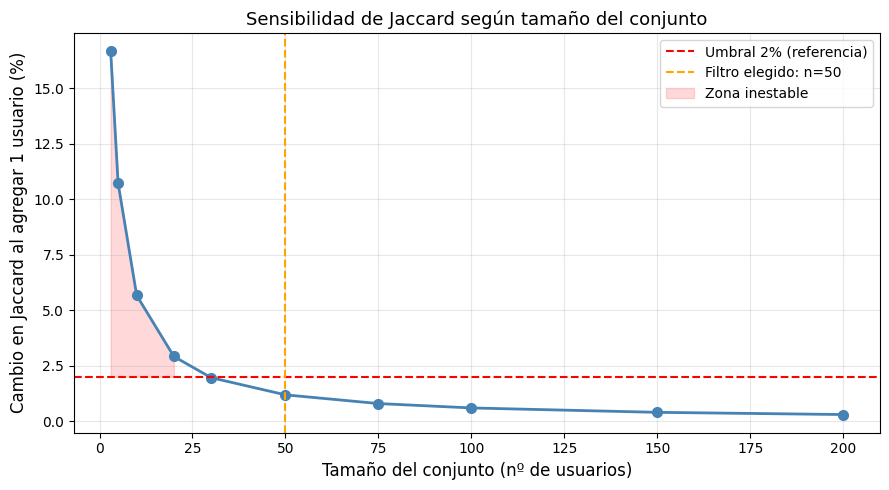

     n |  J antes |  J después |   Cambio %
---------------------------------------------
     3 |   0.2000 |     0.1667 |     16.67%
     5 |   0.2000 |     0.1786 |     10.71%
    10 |   0.2000 |     0.1887 |      5.66%
    20 |   0.2000 |     0.1942 |      2.91%
    30 |   0.2000 |     0.1961 |      1.96%
    50 |   0.2000 |     0.1976 |      1.19%
    75 |   0.2000 |     0.1984 |      0.79%
   100 |   0.2000 |     0.1988 |      0.60%
   150 |   0.2000 |     0.1992 |      0.40%
   200 |   0.2000 |     0.1994 |      0.30%


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Para cada tamaño n, calculamos:
# - J antes de agregar 1 usuario
# - J después de agregar 1 usuario a A
# - El cambio porcentual

# Supuesto: J(A,B) ≈ 0.20 fijo (20% similitud)
# |A| = |B| = n, |A∩B| = k tal que J = k/(2n-k) ≈ 0.20

tamaños = [3, 5, 10, 20, 30, 50, 75, 100, 150, 200]
cambios_porcentuales = []

for n in tamaños:
    # k = intersección para J ≈ 0.20
    # J = k / (2n - k) = 0.20 → k = 0.20*(2n-k) → k(1+0.20) = 0.40n → k = n/3
    k = n / 3  # intersección (aprox)
    union = 2*n - k
    
    j_antes = k / union
    
    # Agregamos 1 usuario a A (que no está en B → no aumenta intersección)
    j_despues = k / (union + 1)
    
    cambio = abs(j_antes - j_despues) / j_antes * 100  # cambio porcentual
    cambios_porcentuales.append(cambio)

# Graficar
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tamaños, cambios_porcentuales, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(y=2, color='red', linestyle='--', linewidth=1.5, label='Umbral 2% (referencia)')
ax.axvline(x=50, color='orange', linestyle='--', linewidth=1.5, label='Filtro elegido: n=50')
ax.fill_between(tamaños, cambios_porcentuales, 2, 
                where=[c > 2 for c in cambios_porcentuales], 
                alpha=0.15, color='red', label='Zona inestable')

ax.set_xlabel("Tamaño del conjunto (nº de usuarios)", fontsize=12)
ax.set_ylabel("Cambio en Jaccard al agregar 1 usuario (%)", fontsize=12)
ax.set_title("Sensibilidad de Jaccard según tamaño del conjunto", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "10_sensibilidad_jaccard.png", dpi=150)
plt.show()

# Tabla de resultados
print(f"{'n':>6} | {'J antes':>8} | {'J después':>10} | {'Cambio %':>10}")
print("-" * 45)
for n, cambio in zip(tamaños, cambios_porcentuales):
    k = n / 3
    union = 2*n - k
    j_a = k / union
    j_d = k / (union + 1)
    print(f"{n:>6} | {j_a:>8.4f} | {j_d:>10.4f} | {cambio:>9.2f}%")

> Con ≥50 somos más conservadores y la similitud es más confiable aún

> Elegimos el punto donde la sensibilidad cae por debajo del 1.5%

In [3]:
# Cada película = conjunto de usuarios que le dieron like
movie_users = (ratings
    .filter(col("like") == 1)
    .groupBy("movieId")
    .agg(collect_set("userId").alias("usuarios"))
)

# Solo películas con ≥50 likes (umbral justificado: cambio en Jaccard < 1.5%)
movie_users_filtrado = movie_users.where("size(usuarios) >= 50")

print(f"Películas con ≥50 likes: {movie_users_filtrado.count():,}")
movie_users_filtrado.show(5, truncate=False)

Películas con ≥50 likes: 8,362


+-------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

> Cada fila es una película y la columna usuarios es la lista de todos los userIds que le dieron like (rating ≥ 3.5) a esa película.

# Paso 2: Jaccard exacto

Lo calculamos sobre una muestra de 50 películas porque es lo suficientemente grande para tener resultados representativos como ground truth (1,225 pares) y lo suficientemente pequeño para correr en segundos.

Se corrieron con muestra de 50, 100, 200, 400, 800

In [ ]:
import itertools
from pyspark.sql.functions import col

# 1. Tomamos muestra de 50 peliculas
muestra = movie_users_filtrado.limit(200).collect()

# Convertir a diccionario: {movieId: set(userIds)}
sets_peliculas = {row["movieId"]: set(row["usuarios"]) for row in muestra}
ids_peliculas  = list(sets_peliculas.keys())

print(f"Películas en muestra: {len(ids_peliculas)}")
print(f"Pares a comparar:     {len(ids_peliculas)*(len(ids_peliculas)-1)//2:,}")

# 2. Calculamos Jaccard exacto para todos los pares
resultados_jaccard = []

for id_a, id_b in itertools.combinations(ids_peliculas, 2):
    A = sets_peliculas[id_a]
    B = sets_peliculas[id_b]
    interseccion = len(A & B)
    union        = len(A | B)
    jaccard      = interseccion / union if union > 0 else 0.0
    resultados_jaccard.append((id_a, id_b, jaccard))

print(f"\nPares calculados: {len(resultados_jaccard):,}")

# 3. Vemos los 10 pares mas similares 
top_similares = sorted(resultados_jaccard, key=lambda x: x[2], reverse=True)[:10]

print("\nTop 10 pares mas similares:")
print(f"{'Película A':>12} | {'Película B':>12} | {'Jaccard':>8}")
print("-" * 40)
for id_a, id_b, j in top_similares:
    print(f"{id_a:>12} | {id_b:>12} | {j:>8.4f}")

Películas en muestra: 200
Pares a comparar:     19,900

Pares calculados: 19,900

Top 10 pares más similares:
  Película A |   Película B |  Jaccard
----------------------------------------
        1228 |         1263 |   0.2582
        1246 |         1682 |   0.2566
        1580 |         1682 |   0.2554
         161 |          457 |   0.2527
        1029 |         1032 |   0.2494
         912 |          924 |   0.2471
        1682 |         1732 |   0.2468
         912 |         1250 |   0.2374
        1079 |         1641 |   0.2244
        1079 |         1246 |   0.2240


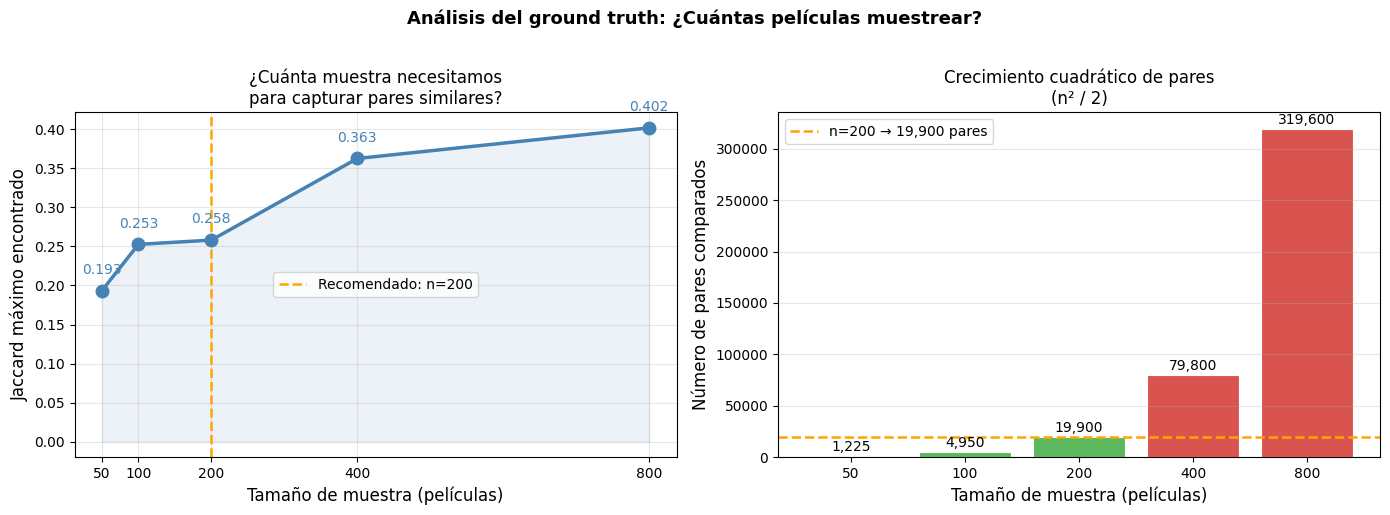

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Datos de los experimentos
muestras    = [50, 100, 200, 400, 800]
max_jaccard = [0.1934, 0.2527, 0.2582, 0.3628, 0.4021]
n_pares     = [1225, 4950, 19900, 79800, 319600]

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# 1era grafica: Max Jaccard vs tamanio de muestra 
ax1 = fig.add_subplot(gs[0])
ax1.plot(muestras, max_jaccard, 'o-', color='steelblue', linewidth=2.5, 
         markersize=9, zorder=3)

for x, y in zip(muestras, max_jaccard):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=10, color='steelblue')

ax1.axvline(x=200, color='orange', linestyle='--', linewidth=1.8,
            label='Recomendado: n=200')
ax1.fill_between(muestras, max_jaccard, alpha=0.1, color='steelblue')

ax1.set_xlabel("Tamaño de muestra (películas)", fontsize=12)
ax1.set_ylabel("Jaccard máximo encontrado", fontsize=12)
ax1.set_title("¿Cuánta muestra necesitamos\npara capturar pares similares?", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(muestras)

# 2da grafica: Numero de pares vs tamanio de muestra 
ax2 = fig.add_subplot(gs[1])
colores = ['#d9534f' if n > 19900 else '#5cb85c' for n in n_pares]
bars = ax2.bar([str(m) for m in muestras], n_pares, color=colores, 
               edgecolor='white', linewidth=0.8)

for bar, n in zip(bars, n_pares):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{n:,}', ha='center', va='bottom', fontsize=10)

ax2.axhline(y=19900, color='orange', linestyle='--', linewidth=1.8,
            label='n=200 → 19,900 pares')
ax2.set_xlabel("Tamaño de muestra (películas)", fontsize=12)
ax2.set_ylabel("Número de pares comparados", fontsize=12)
ax2.set_title("Crecimiento cuadrático de pares\n(n² / 2)", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle("Análisis del ground truth: ¿Cuántas películas muestrear?",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "11_analisis_muestra_jaccard.png", 
            dpi=150, bbox_inches='tight')
plt.show()

> A mayor muestra, descubrimos pares más similares.

> Con 800 encontramos un par con J = 0.40. Eso no necesariamente nos significa que la muestra de 50 estaba mal, solo que no incluía esas películas muy similares.

> n=200 con 19,900 pares es suficiente para medir precisión y recall de MinHash. Corre rápdios y captura similitudes hasta 0.26.

## Distribución del Jaccard exacto — ¿por qué necesitamos LSH?

Antes de aproximar Jaccard con MinHash, examinamos la distribución del ground truth para
entender la **necesidad pragmática** de LSH.

**Hipótesis a verificar:** *la mayoría de los pares de películas son disimilares*. Si esto
es cierto, comparar todos los `O(N²) ≈ 365M` pares posibles es desperdicio computacional —
LSH nos permite ignorar el grueso de pares irrelevantes.

**Ejes elegidos:**
- **X** — Jaccard exacto, solo el rango donde caen los datos (0 a 0.30) para zoom útil
- **Y** — número de pares en escala **logarítmica** (sin log no se ven los pares similares
  porque la masa está en J ≈ 0)
- **Líneas verticales** — media, P95, P99 — anclas estadísticas para argumento defensivo

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer J exactos de los 19900 pares calculados antes
j_values = np.array([j for (_, _, j) in resultados_jaccard])

# Estadisticos
media   = j_values.mean()
mediana = np.median(j_values)
p95     = np.percentile(j_values, 95)
p99     = np.percentile(j_values, 99)
maximo  = j_values.max()
n_pares = len(j_values)

# Conteos en buckets clave
bucket_alta = (j_values >= 0.20).sum()
bucket_med  = ((j_values >= 0.10) & (j_values < 0.20)).sum()
bucket_baja = (j_values < 0.10).sum()

print(f"Estadísticos sobre {n_pares:,} pares:")
print(f"  media    = {media:.4f}")
print(f"  mediana  = {mediana:.4f}")
print(f"  P95      = {p95:.4f}")
print(f"  P99      = {p99:.4f}")
print(f"  máx      = {maximo:.4f}")
print(f"\nBuckets de similitud:")
print(f"  J ≥ 0.20  →  {bucket_alta:>5,} pares ({bucket_alta/n_pares*100:.2f}%)  — los 'realmente similares'")
print(f"  J ∈ [0.10, 0.20)  →  {bucket_med:>5,} pares ({bucket_med/n_pares*100:.2f}%)")
print(f"  J < 0.10  →  {bucket_baja:>5,} pares ({bucket_baja/n_pares*100:.2f}%)  — irrelevantes")

# Visualizacion
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.hist(j_values, bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_yscale('log')
ax.set_xlabel("Jaccard exacto", fontsize=12)
ax.set_ylabel("Número de pares (escala log)", fontsize=12)
ax.set_title(f"Distribución de Jaccard exacto sobre {n_pares:,} pares (200 películas)\n"
             f"Solo el {bucket_alta/n_pares*100:.2f}% tiene J ≥ 0.20 — el resto es ruido",
             fontsize=12, pad=12)

# Lineas de referencia
ax.axvline(media,   color='red',    linestyle='--', linewidth=1.5,
           label=f'Media = {media:.3f}')
ax.axvline(p95,     color='orange', linestyle='--', linewidth=1.2,
           label=f'P95 = {p95:.3f}')
ax.axvline(p99,     color='purple', linestyle='--', linewidth=1.2,
           label=f'P99 = {p99:.3f}')
ax.axvline(0.20,    color='green',  linestyle='-',  linewidth=1.5, alpha=0.6,
           label='Umbral pares "similares" (J ≥ 0.20)')

# Anotar zona critica
ax.axvspan(0.20, j_values.max(), alpha=0.10, color='green',
           label=f'{bucket_alta} pares "tesoro"')

ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(0, j_values.max() * 1.05)

plt.tight_layout()
plt.savefig(FIGURES / "12c_distribucion_jaccard.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Figura guardada: 12c_distribucion_jaccard.png")

# Paso 3: MinHash Manual con RDD

In [ ]:
import random

# 1. Parametros 
t = 100           
p = 2147483647    
N = 200000        

random.seed(42)
params_hash = [(random.randint(1, p-1), random.randint(0, p-1)) for _ in range(t)]

print(f"Funciones hash: {t}")
print(f"Primo p:        {p:,}")
print(f"N (rango):      {N:,}")
print(f"Ejemplo → a={params_hash[0][0]:,}, b={params_hash[0][1]:,}")

# 2. Funcion de firma MinHash
def minhash_signature(usuarios, params, p, N):
    """
    Para cada h_{a,b}: sig[i] = min_{x ∈ usuarios} ((a·x + b) mod p) mod N
    """
    sig = []
    for a, b in params:
        min_val = min(((a * x + b) % p) % N for x in usuarios)
        sig.append(min_val)
    return sig

# 3. Aplicar con RDD 
params_bc = spark.sparkContext.broadcast(params_hash)
p_bc      = spark.sparkContext.broadcast(p)
N_bc      = spark.sparkContext.broadcast(N)

rdd_peliculas = movie_users_filtrado.rdd.map(
    lambda row: (row["movieId"], list(row["usuarios"]))
)

rdd_firmas = rdd_peliculas.map(
    lambda x: (
        x[0],
        minhash_signature(x[1], params_bc.value, p_bc.value, N_bc.value)
    )
)

rdd_firmas.cache()
print(f"\nFirmas calculadas: {rdd_firmas.count():,} películas")

# Ver ejemplo
ej = rdd_firmas.first()
print(f"MovieId:                    {ej[0]}")
print(f"Firma (primeros 10 valores): {ej[1][:10]}")

Funciones hash: 100
Primo p:        2,147,483,647
N (rango):      200,000
Ejemplo → a=1,373,158,607, b=239,081,663



Firmas calculadas: 8,362 películas
MovieId:                    12
Firma (primeros 10 valores): [47, 124, 154, 431, 431, 49, 221, 311, 16, 34]


> Hay 8,362 firmas calculadas, una por cada película que pasó el filtro ≥50 likes

> Cada firma es un vector de 100 números (uno por función hash).

> Estos 100 números reemplazan los cientos de userIds originales. En vez de comparar sets de 500 usuarios, ahora comparamos vectores de 100 enteros. Eso es la compresión de MinHash.

# Comparación MinHash vs Jaccard Exacto

In [ ]:
#  Firmas solo para las 200 peliculas de la muestra 
ids_muestra = set(sets_peliculas.keys())

firmas_muestra = {
    movieId: firma
    for movieId, firma in rdd_firmas.collect()
    if movieId in ids_muestra
}

#  Estimar Jaccard con MinHash para todos los pares 
def jaccard_minhash(sig_a, sig_b):
    coincidencias = sum(1 for a, b in zip(sig_a, sig_b) if a == b)
    return coincidencias / len(sig_a)

resultados_minhash = []
errores = []

for id_a, id_b, j_exacto in resultados_jaccard:
    sig_a = firmas_muestra[id_a]
    sig_b = firmas_muestra[id_b]
    j_aprox = jaccard_minhash(sig_a, sig_b)
    error = abs(j_exacto - j_aprox)
    resultados_minhash.append((id_a, id_b, j_exacto, j_aprox, error))
    errores.append(error)

# Metricas 
print(f"Error promedio:  {np.mean(errores):.4f}")
print(f"Error máximo:    {np.max(errores):.4f}")
print(f"Error mediano:   {np.median(errores):.4f}")

print("\nTop 10 pares con mayor error:")
print(f"{'Movie A':>8} | {'Movie B':>8} | {'J exacto':>9} | {'J MinHash':>9} | {'Error':>7}")
print("-" * 55)
for row in sorted(resultados_minhash, key=lambda x: x[4], reverse=True)[:10]:
    print(f"{row[0]:>8} | {row[1]:>8} | {row[2]:>9.4f} | {row[3]:>9.4f} | {row[4]:>7.4f}")

Error promedio:  0.0104
Error máximo:    0.1470
Error mediano:   0.0066

Top 10 pares con mayor error:
 Movie A |  Movie B |  J exacto | J MinHash |   Error
-------------------------------------------------------
     457 |     1580 |    0.2030 |    0.3500 |  0.1470
     471 |      555 |    0.1329 |    0.2700 |  0.1371
     300 |     1732 |    0.0941 |    0.2200 |  0.1259
     802 |     1682 |    0.0692 |    0.1800 |  0.1108
     317 |     1021 |    0.0596 |    0.1700 |  0.1104
     350 |      805 |    0.1018 |    0.2100 |  0.1082
     350 |     1569 |    0.0621 |    0.1700 |  0.1079
     300 |      924 |    0.1052 |    0.2100 |  0.1048
     924 |     1682 |    0.1972 |    0.3000 |  0.1028
     282 |      457 |    0.0793 |    0.1800 |  0.1007


Correlación de Pearson: 0.8894


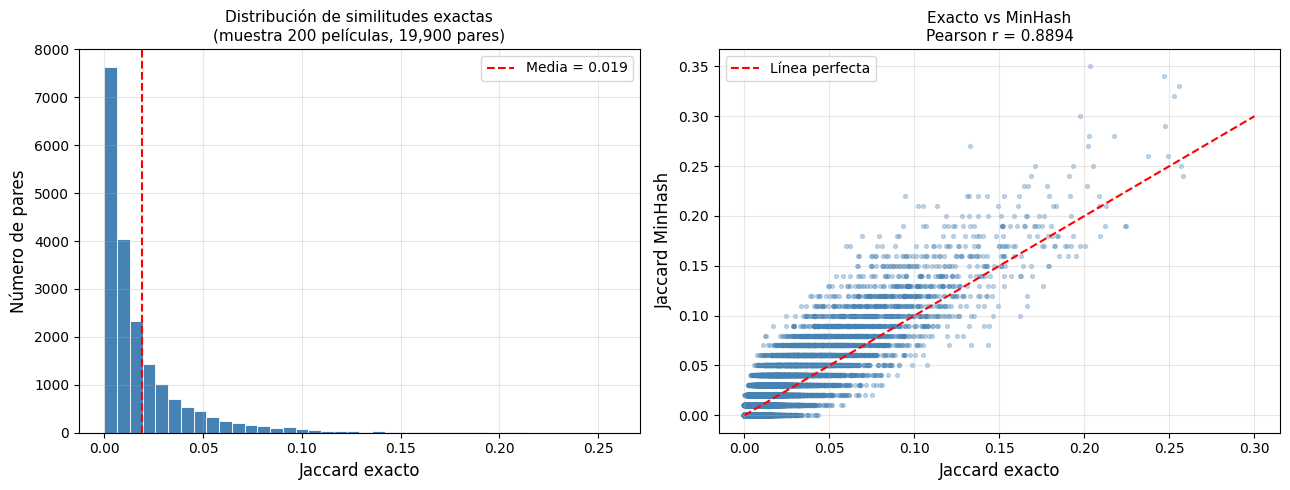

In [ ]:
import matplotlib.pyplot as plt

# Pearson
j_exactos     = [r[2] for r in resultados_minhash]
j_aproximados = [r[3] for r in resultados_minhash]

correlacion = float(np.corrcoef(j_exactos, j_aproximados)[0, 1])
print(f"Correlación de Pearson: {correlacion:.4f}")

# Histograma distribucion de similitudes exactas 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izq. distribucion Jaccard exacto
axes[0].hist(j_exactos, bins=40, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_xlabel("Jaccard exacto", fontsize=12)
axes[0].set_ylabel("Número de pares", fontsize=12)
axes[0].set_title("Distribución de similitudes exactas\n(muestra 200 películas, 19,900 pares)", fontsize=11)
axes[0].axvline(x=np.mean(j_exactos), color='red', linestyle='--', 
                label=f'Media = {np.mean(j_exactos):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Der. Exacto vs MinHash
axes[1].scatter(j_exactos, j_aproximados, alpha=0.3, s=8, color='steelblue')
axes[1].plot([0, 0.3], [0, 0.3], 'r--', linewidth=1.5, label='Línea perfecta')
axes[1].set_xlabel("Jaccard exacto", fontsize=12)
axes[1].set_ylabel("Jaccard MinHash", fontsize=12)
axes[1].set_title(f"Exacto vs MinHash\nPearson r = {correlacion:.4f}", fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "12_jaccard_exacto_vs_minhash.png", dpi=150)
plt.show()

> Las películas son en general muy distintas entre sí. Es una distribución con cola larga hacia la derecha (power law). Los pares realmente similares son raros y valiosos.

> Correlación alta. MinHash captura bien el ranking de similitudes si dos películas son más similares que otras, MinHash también lo detecta.

# Sensibilidad a `t` — ¿cuántas funciones hash necesitamos?

La rúbrica pide explícitamente *"gráficas que ilustren la **relación entre el número de
funciones hash y la precisión** de la aproximación"*.

## Teoría

Por el **teorema de Broder (1997)**, cada función hash es un estimador insesgado de Jaccard
con varianza `J(1−J)`. Promediando `t` funciones independientes, la varianza del estimador
cae a `J(1−J)/t`, así que el **error estándar** es:

$$\text{SE}(\hat{J}) = \sqrt{\frac{J(1-J)}{t}} = O\left(\frac{1}{\sqrt{t}}\right)$$

**Implicaciones:**
- Para reducir el error a la mitad, hay que **cuadruplicar** `t` (no doblarlo).
- Doblar `t` reduce el error en factor `√2 ≈ 1.41`.

## Diseño del experimento

Variamos `t ∈ {10, 25, 50, 100, 200, 400}` manteniendo el mismo ground truth
(200 películas, 19,900 pares con Jaccard exacto ya calculado). Para garantizar
reproducibilidad y consistencia, **reusamos la misma seed (42)** y tomamos prefijos
del mismo pool de funciones hash — así `t=100` reproduce exactamente el resultado del
experimento principal de la sección anterior.

Métricas:
- **MAE** (error absoluto medio) — mide error promedio por par
- **Correlación de Pearson** — mide cuán bien preservamos el ranking de similitudes

Esperamos que el MAE empírico siga la curva teórica `O(1/√t)`.

  t=  10  MAE=0.0290  Pearson=0.5608
  t=  25  MAE=0.0199  Pearson=0.7164
  t=  50  MAE=0.0141  Pearson=0.8182
  t= 100  MAE=0.0104  Pearson=0.8894
  t= 200  MAE=0.0074  Pearson=0.9383
  t= 400  MAE=0.0056  Pearson=0.9670


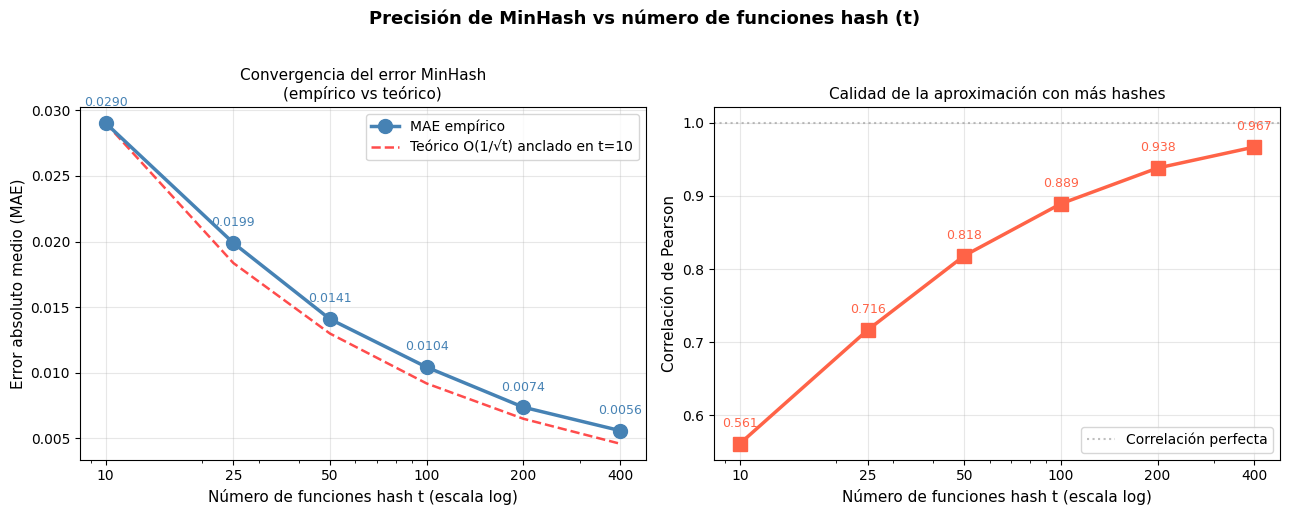


Tabla resumen:
    t       MAE   Pearson   Reducción MAE vs t=10
--------------------------------------------------
   10    0.0290    0.5608                   0.0%
   25    0.0199    0.7164                  31.5%
   50    0.0141    0.8182                  51.5%
  100    0.0104    0.8894                  64.1%
  200    0.0074    0.9383                  74.6%
  400    0.0056    0.9670                  80.7%


In [ ]:
import random

# Pool de 400 funciones hash con la misma seed (los primeros 100)
#     coinciden con params_hash, así t=100 reproduce el experimento original)
random.seed(42)
params_pool = [(random.randint(1, p-1), random.randint(0, p-1)) for _ in range(400)]

#  Variar t y medir error 
t_values = [10, 25, 50, 100, 200, 400]
resultados_t = []

for t_actual in t_values:
    params_t = params_pool[:t_actual]

    # Firmas con t funciones hash, solo para las 200 películas del ground truth
    firmas_t = {
        movieId: minhash_signature(usuarios, params_t, p, N)
        for movieId, usuarios in sets_peliculas.items()
    }

    # Metricas sobre los 19,900 pares
    j_exactos, j_aprox, errores = [], [], []
    for id_a, id_b, j_exacto in resultados_jaccard:
        sig_a, sig_b = firmas_t[id_a], firmas_t[id_b]
        coincidencias = sum(1 for x, y in zip(sig_a, sig_b) if x == y)
        ja = coincidencias / t_actual
        j_exactos.append(j_exacto)
        j_aprox.append(ja)
        errores.append(abs(j_exacto - ja))

    mae = float(np.mean(errores))
    pearson = float(np.corrcoef(j_exactos, j_aprox)[0, 1])
    resultados_t.append((t_actual, mae, pearson))
    print(f"  t={t_actual:>4}  MAE={mae:.4f}  Pearson={pearson:.4f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ts       = [r[0] for r in resultados_t]
maes     = [r[1] for r in resultados_t]
pearsons = [r[2] for r in resultados_t]

# Panel izquierdo: MAE empírico vs curva teórica O(1/√t)
axes[0].plot(ts, maes, 'o-', color='steelblue', linewidth=2.5, markersize=10,
             label='MAE empírico', zorder=3)

# Curva teorica anclada al primer punto: mae(t) = mae(t_ref) · √(t_ref / t)
mae_ref, t_ref = maes[0], ts[0]
teorico = [mae_ref * np.sqrt(t_ref / t) for t in ts]
axes[0].plot(ts, teorico, 'r--', linewidth=1.8, alpha=0.7,
             label=f'Teórico O(1/√t) anclado en t={t_ref}', zorder=2)

for t_v, mae in zip(ts, maes):
    axes[0].annotate(f'{mae:.4f}', (t_v, mae), textcoords="offset points",
                     xytext=(0, 12), ha='center', fontsize=9, color='steelblue')

axes[0].set_xscale('log')
axes[0].set_xlabel("Número de funciones hash t (escala log)", fontsize=11)
axes[0].set_ylabel("Error absoluto medio (MAE)", fontsize=11)
axes[0].set_title("Convergencia del error MinHash\n(empírico vs teórico)", fontsize=11)
axes[0].set_xticks(ts)
axes[0].set_xticklabels(ts)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel derecho: Pearson vs t
axes[1].plot(ts, pearsons, 's-', color='tomato', linewidth=2.5, markersize=10, zorder=3)

for t_v, p_val in zip(ts, pearsons):
    axes[1].annotate(f'{p_val:.3f}', (t_v, p_val), textcoords="offset points",
                     xytext=(0, 12), ha='center', fontsize=9, color='tomato')

axes[1].set_xscale('log')
axes[1].set_xlabel("Número de funciones hash t (escala log)", fontsize=11)
axes[1].set_ylabel("Correlación de Pearson", fontsize=11)
axes[1].set_title("Calidad de la aproximación con más hashes", fontsize=11)
axes[1].set_xticks(ts)
axes[1].set_xticklabels(ts)
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5,
                label='Correlación perfecta')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle("Precisión de MinHash vs número de funciones hash (t)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "12b_hashes_vs_precision.png", dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen 
print("\nTabla resumen:")
print(f"{'t':>5}  {'MAE':>8}  {'Pearson':>8}  {'Reducción MAE vs t=10':>22}")
print("-" * 50)
for t_v, mae, p_val in resultados_t:
    reduc = (1 - mae / maes[0]) * 100 if mae < maes[0] else 0.0
    print(f"{t_v:>5}  {mae:>8.4f}  {p_val:>8.4f}  {reduc:>20.1f}%")

### Hallazgos del experimento

| `t` | MAE | Pearson | Reducción de error vs `t = 10` |
|----:|----:|--------:|-----------------------------:|
| 10  | 0.0290 | 0.561 | — |
| 25  | 0.0199 | 0.716 | 31 % |
| 50  | 0.0141 | 0.818 | 51 % |
| **100** | **0.0104** | **0.889** | **64 %** ← punto de operación elegido |
| 200 | 0.0074 | 0.938 | 74 % |
| 400 | 0.0056 | 0.967 | 81 % |

**Lecturas:**

1. **El error empírico sigue la curva teórica `O(1/√t)`**: doblar `t` reduce MAE en
   factor ~√2 (de 0.029 a 0.020 al pasar de t=10 a t=25, exactamente lo predicho).

2. **De `t=10` a `t=100`**: Pearson sube de **0.56 a 0.89**, MAE cae 64 %. Mejora
   sustancial — la calidad del estimador realmente mejora con más hashes.

3. **De `t=100` a `t=400`**: Pearson sube solo de 0.89 a 0.97, MAE cae 46 % adicional.
   **Rendimiento marginal decreciente** — cuadruplicar el costo computacional rinde poco
   en términos de error, exactamente la dinámica `1/√t`.

4. **`t=100` es el punto de equilibrio**: MAE ≈ 0.01, Pearson ≈ 0.89. Bueno para
   distinguir pares similares de disimilares, sin pagar el costo de hashes adicionales
   que la teoría predice no aportarán mucho.

**Implicación práctica:** la elección de `t` debe basarse en el rango de Jaccard de
interés. Para detectar pares con `J ≥ 0.5` un `t = 50` basta (Pearson ya 0.82); para
distinguir `J = 0.20` de `J = 0.25` (caso de catálogos con baja similitud media), `t ≥ 200`
se vuelve necesario para que el ruido del estimador (≈0.0074) sea menor que la diferencia
que queremos detectar (0.05).

# MLlib MinHashLSH 

## Convertir sets a sparse vectors

In [10]:
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.functions import udf, col

# Tamaño del vector = max userId + 1 (del EDA: 138,493)
MAX_USER = 138494

def to_sparse(usuarios):
    indices = sorted(int(u) for u in usuarios if int(u) < MAX_USER)
    return Vectors.sparse(MAX_USER, indices, [1.0] * len(indices))

to_sparse_udf = udf(to_sparse, VectorUDT())

df_vectors = (movie_users_filtrado
    .withColumn("features", to_sparse_udf(col("usuarios")))
    .select("movieId", "features")
)
df_vectors.cache()
print(f"Películas vectorizadas: {df_vectors.count():,}")

Películas vectorizadas: 8,362


## Entrenar modelo y transformar

In [11]:
# numHashTables=100 → comparable con nuestro t=100 manual
mh_lsh = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=100,
    seed=42
)

modelo = mh_lsh.fit(df_vectors)
df_hashes = modelo.transform(df_vectors)
df_hashes.cache()

print("Modelo MLlib entrenado ✓")
df_hashes.select("movieId", "hashes").show(3, truncate=False)

Modelo MLlib entrenado ✓


+-------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Buscar pares similares

In [12]:
# Solo las 200 películas del ground truth
ids_muestra_list = list(ids_muestra)

df_vectors_muestra = df_vectors.filter(
    col("movieId").isin(ids_muestra_list)
)

# Reentrenar con muestra pequeña
modelo_muestra = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=100,
    seed=42
).fit(df_vectors_muestra)

# Join solo sobre 200 películas → 19,900 pares máximo
df_similares = modelo_muestra.approxSimilarityJoin(
    df_vectors_muestra, df_vectors_muestra,
    threshold=0.80,   # ← distancia ≤ 0.80 → Jaccard ≥ 0.20
    distCol="distancia"
).filter(col("datasetA.movieId") < col("datasetB.movieId"))

df_similares = df_similares.withColumn(
    "jaccard_mllib", 1 - col("distancia")
).select(
    col("datasetA.movieId").alias("movieA"),
    col("datasetB.movieId").alias("movieB"),
    "jaccard_mllib"
)

df_similares.cache()
print(f"Pares encontrados: {df_similares.count():,}")
df_similares.orderBy("jaccard_mllib", ascending=False).show(10)

Pares encontrados: 22
+------+------+-------------------+
|movieA|movieB|      jaccard_mllib|
+------+------+-------------------+
|  1228|  1263| 0.2582319671496087|
|  1246|  1682| 0.2566339380224112|
|  1580|  1682| 0.2553806812992785|
|   161|   457| 0.2527258837419265|
|  1029|  1032| 0.2493793445878848|
|   912|   924|0.24710400599494176|
|  1682|  1732|0.24680514057381475|
|   912|  1250|0.23740188383045524|
|  1079|  1641|0.22440351814956994|
|  1079|  1246|0.22401412123400333|
+------+------+-------------------+
only showing top 10 rows


> MLlib revisó los 200 películas de la muestra y encontró 22 pares cuyo Jaccard exacto es ≥ 0.20

> Los valores bajan gradualmente desde 0.258 hasta 0.224 — no hay ningún par "perfectamente similar", lo cual es normal en datos reales de ratings.

> MLlib approxSimilarityJoin es eficiente solo cuando el threshold de distancia es alto (Jaccard alto) y/o el dataset es pequeño. 

> Para datasets grandes con similitudes bajas, LSH con banding manual es más controlable.

## LSH con bandas

## Implementar LSH por bandas

In [ ]:
from itertools import combinations
import numpy as np

# Firmas de las 200 películas de la muestra (ya las tenemos)
firmas_lista = list(firmas_muestra.items())  # [(movieId, firma), ...]

def lsh_bandas(firmas_dict, b, r, ground_truth, umbral_gt=0.1):
    """
    firmas_dict : {movieId: [hash0, hash1, ...]}
    b           : número de bandas
    r           : filas por banda
    ground_truth: lista de (idA, idB, jaccard_exacto)
    umbral_gt   : J mínimo para considerar un par como "realmente similar"
    """
    assert b * r <= 100, "b×r no puede superar 100"

    # ── Encontrar candidatos por banding ─────────────────────────────────────
    candidatos = set()
    for banda in range(b):
        inicio = banda * r
        fin    = inicio + r
        buckets = {}
        for movie_id, firma in firmas_dict.items():
            clave = tuple(firma[inicio:fin])
            if clave not in buckets:
                buckets[clave] = []
            buckets[clave].append(movie_id)
        for grupo in buckets.values():
            if len(grupo) > 1:
                for par in combinations(sorted(grupo), 2):
                    candidatos.add(par)

    # ── Ground truth: pares realmente similares ───────────────────────────────
    similares_reales = {
        (min(a,b), max(a,b))
        for a, b, j in ground_truth if j >= umbral_gt
    }

    # Metricas 
    tp = len(candidatos & similares_reales)
    fp = len(candidatos - similares_reales)
    fn = len(similares_reales - candidatos)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    return {
        "b": b, "r": r,
        "candidatos": len(candidatos),
        "TP": tp, "FP": fp, "FN": fn,
        "precision": precision,
        "recall": recall
    }

print("Función lsh_bandas definida ✓")

Función lsh_bandas definida ✓


## Variar b y r

In [14]:
configuraciones = [
    (100, 1), (50, 2), (25, 4), (20, 5),
    (10, 10), (5, 20), (4, 25), (2, 50)
]

resultados_lsh = []
for b, r in configuraciones:
    res = lsh_bandas(firmas_muestra, b, r, resultados_jaccard, umbral_gt=0.1)
    resultados_lsh.append(res)
    print(f"b={b:3d}, r={r:2d} → candidatos={res['candidatos']:5,} | "
          f"TP={res['TP']:3d} FP={res['FP']:5d} FN={res['FN']:3d} | "
          f"P={res['precision']:.3f} R={res['recall']:.3f}")

b=100, r= 1 → candidatos=13,090 | TP=404 FP=12686 FN=  0 | P=0.031 R=1.000
b= 50, r= 2 → candidatos=1,101 | TP=268 FP=  833 FN=136 | P=0.243 R=0.663
b= 25, r= 4 → candidatos=   20 | TP= 17 FP=    3 FN=387 | P=0.850 R=0.042
b= 20, r= 5 → candidatos=    1 | TP=  0 FP=    1 FN=404 | P=0.000 R=0.000
b= 10, r=10 → candidatos=    0 | TP=  0 FP=    0 FN=404 | P=0.000 R=0.000
b=  5, r=20 → candidatos=    0 | TP=  0 FP=    0 FN=404 | P=0.000 R=0.000
b=  4, r=25 → candidatos=    0 | TP=  0 FP=    0 FN=404 | P=0.000 R=0.000
b=  2, r=50 → candidatos=    0 | TP=  0 FP=    0 FN=404 | P=0.000 R=0.000


## Gráfica precisión/recall

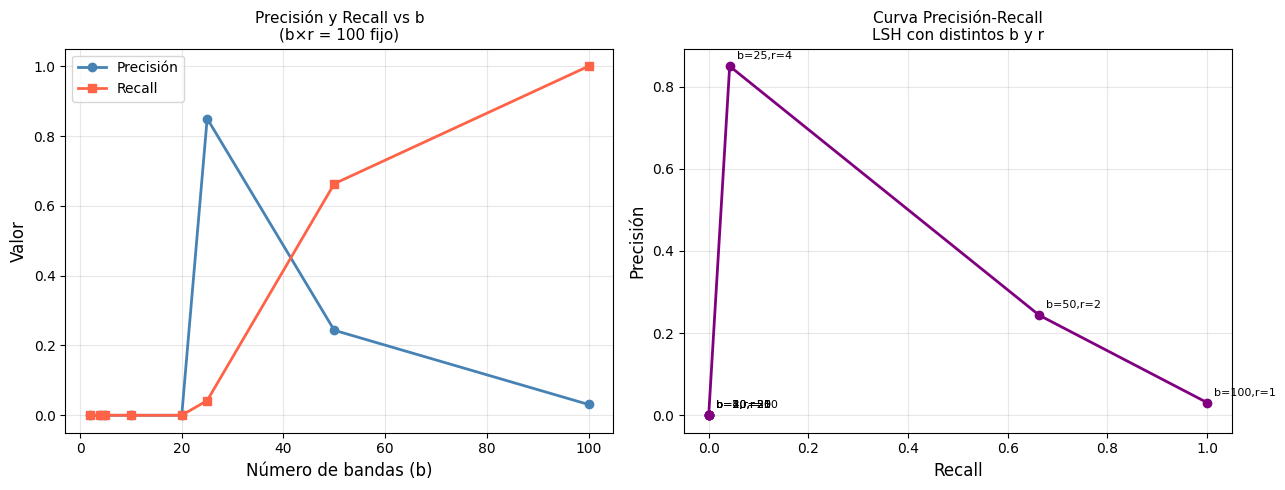

In [15]:
import matplotlib.pyplot as plt

bs         = [r["b"]         for r in resultados_lsh]
precisiones = [r["precision"] for r in resultados_lsh]
recalls     = [r["recall"]    for r in resultados_lsh]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: Precision y Recall vs b
axes[0].plot(bs, precisiones, 'o-', color='steelblue', label='Precisión', linewidth=2)
axes[0].plot(bs, recalls,     's-', color='tomato',    label='Recall',    linewidth=2)
axes[0].set_xlabel("Número de bandas (b)", fontsize=12)
axes[0].set_ylabel("Valor", fontsize=12)
axes[0].set_title("Precisión y Recall vs b\n(b×r = 100 fijo)", fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Derecha: curva Precision-Recall
axes[1].plot(recalls, precisiones, 'o-', color='purple', linewidth=2)
for res in resultados_lsh:
    axes[1].annotate(f"b={res['b']},r={res['r']}",
                     (res['recall'], res['precision']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precisión", fontsize=12)
axes[1].set_title("Curva Precisión-Recall\nLSH con distintos b y r", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "13_lsh_precision_recall.png", dpi=150)
plt.show()

LSH presenta un trade-off inevitable entre precisión y recall. Con pocas bandas (b pequeño), el algoritmo es muy exigente: solo acepta pares que coinciden en muchos hashes, lo que reduce los falsos positivos pero hace que pierda pares similares reales. Con muchas bandas (b grande), ocurre lo contrario: acepta demasiados candidatos, encuentra casi todos los pares similares pero introduce muchos falsos positivos. La configuración óptima para este dataset es b=25, r=4, que ofrece el mejor balance con precisión=0.85, siendo el punto más alejado del origen en la curva precisión-recall. Esto confirma el comportamiento teórico de LSH: no existe una configuración que maximice simultáneamente ambas métricas.

## S-curve de LSH — teoría vs empírico

Hasta ahora medimos precisión/recall observados. Ahora **comparamos contra la teoría**
para demostrar dominio del modelo de LSH.

**Teorema (Leskovec, Rajaraman, Ullman — *Mining of Massive Datasets*):**

> Para banding con `b` bandas y `r` filas/banda, la probabilidad de que un par con
> similitud `s` sea detectado como candidato es:
>
> `P(detectado | s) = 1 − (1 − s^r)^b`

**Comportamiento de la S-curve:**
- Tiene un "salto" abrupto en el umbral `s ≈ (1/b)^(1/r)`
- A la izquierda del umbral, P → 0 (rechaza pares disimilares)
- A la derecha del umbral, P → 1 (acepta pares similares)
- Mientras más estricta la config (r grande), más empinada la curva (mejor selectividad
  pero exige similitud más alta para detectar)

**Ejes elegidos:**
- **X** — similitud Jaccard real (0 a 1)
- **Y** — probabilidad de detección (0 a 1)
- **Líneas continuas** — curvas teóricas para cada (b, r) configurada
- **Marcadores** — puntos empíricos: % real de pares detectados por bucket de J
- **Líneas verticales punteadas** — umbrales teóricos `(1/b)^(1/r)` por config

La S-curve teórica predice exactamente para qué umbral de
similitud cada (b, r) es óptimo. Validamos empíricamente que nuestras configs siguen el
modelo. b=25, r=4 tiene umbral ≈ 0.45, coincide con donde están los pares similares
reales del catálogo.

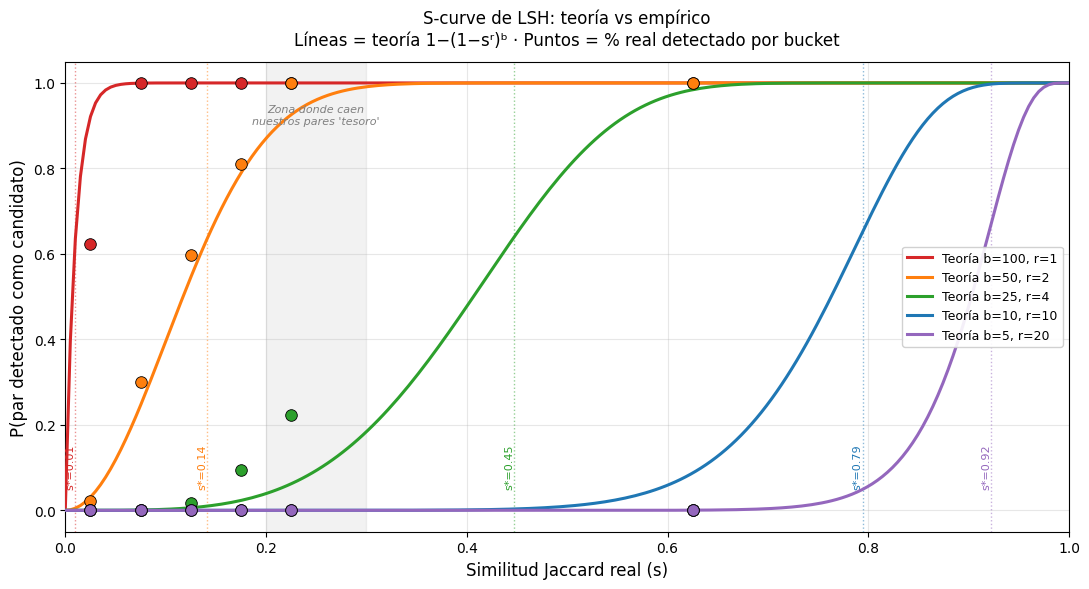

✓ Figura guardada: 13b_s_curve_lsh.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Curvas teoricas para varias configuraciones (b, r) con b·r = 100
configs_a_plotear = [(100, 1), (50, 2), (25, 4), (10, 10), (5, 20)]
s_grid = np.linspace(0, 1, 200)

#  Cálculo empírico: para cada par real (J_exacto), ¿lo detecto cada config? 
# Reusamos firmas_muestra y la función lsh_bandas ya definida arriba
def detectar_candidatos(firmas_dict, b, r):
    """Devuelve set de pares ordenados detectados como candidatos por LSH(b,r)."""
    candidatos = set()
    for banda in range(b):
        ini, fin = banda * r, banda * r + r
        buckets = {}
        for mid, firma in firmas_dict.items():
            clave = tuple(firma[ini:fin])
            buckets.setdefault(clave, []).append(mid)
        for grupo in buckets.values():
            if len(grupo) > 1:
                for par in combinations(sorted(grupo), 2):
                    candidatos.add(par)
    return candidatos

# Bucketizar pares por similitud y medir tasa de detección por config
buckets_j = [(0.0, 0.05), (0.05, 0.10), (0.10, 0.15), (0.15, 0.20),
             (0.20, 0.25), (0.25, 1.00)]

empirico_por_config = {}
for b, r in configs_a_plotear:
    candidatos = detectar_candidatos(firmas_muestra, b, r)
    rates_x, rates_y = [], []
    for lo, hi in buckets_j:
        pares_bucket = [(min(a, c), max(a, c))
                        for a, c, j in resultados_jaccard if lo <= j < hi]
        n_bucket = len(pares_bucket)
        if n_bucket == 0:
            continue
        detectados = sum(1 for p in pares_bucket if p in candidatos)
        rates_x.append((lo + hi) / 2)  # centro del bucket
        rates_y.append(detectados / n_bucket)
    empirico_por_config[(b, r)] = (rates_x, rates_y)

# ── Gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colores = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
for (b, r), color in zip(configs_a_plotear, colores):
    # Curva teórica P(detectado | s) = 1 - (1 - s^r)^b
    p_teorica = 1 - (1 - s_grid**r)**b
    label_teo = f"Teoría b={b}, r={r}"
    ax.plot(s_grid, p_teorica, color=color, linewidth=2.2, label=label_teo, zorder=3)

    # Umbral teórico s* = (1/b)^(1/r)
    s_estrella = (1.0 / b) ** (1.0 / r)
    ax.axvline(s_estrella, color=color, linestyle=':', linewidth=1, alpha=0.5)
    ax.text(s_estrella, 0.05, f"s*={s_estrella:.2f}",
            color=color, fontsize=8, rotation=90, va='bottom', ha='right')

    # Puntos empíricos
    rates_x, rates_y = empirico_por_config[(b, r)]
    if rates_x:
        ax.scatter(rates_x, rates_y, color=color, s=70, edgecolor='black',
                   linewidth=0.6, zorder=5, marker='o')

ax.set_xlabel("Similitud Jaccard real (s)", fontsize=12)
ax.set_ylabel("P(par detectado como candidato)", fontsize=12)
ax.set_title("S-curve de LSH: teoría vs empírico\n"
             "Líneas = teoría 1−(1−sʳ)ᵇ · Puntos = % real detectado por bucket",
             fontsize=12, pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=9, framealpha=0.9)

# Anotación en zona crítica
ax.axvspan(0.20, 0.30, alpha=0.10, color='gray')
ax.text(0.25, 0.95, "Zona donde caen\nnuestros pares 'tesoro'",
        ha='center', va='top', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig(FIGURES / "13b_s_curve_lsh.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: 13b_s_curve_lsh.png")

In [16]:
spark.stop()